In [9]:
from google.colab import drive
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

drive.mount('/content/drive')

plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid", palette="muted")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
search_pattern = '/content/drive/MyDrive/TUGAS AKHIR/**/target_birds_manifest.csv'
manifest_files = glob.glob(search_pattern, recursive=True)

if manifest_files:
    manifest_path = manifest_files[0]
    print(f"✅ Berkas manifes ditemukan: {manifest_path}")
else:
    manifest_path = '/content/drive/MyDrive/TUGAS AKHIR/data/manifests/target_birds_manifest.csv'
    print(f"⚠️ Menggunakan path fallback: {manifest_path}")

df_raw = pd.read_csv(manifest_path)

split_path = os.path.join(os.path.dirname(manifest_path), 'dataset_split.csv')
if os.path.exists(split_path):
    df_split = pd.read_csv(split_path)
    if 'split_role' in df_split.columns:
        df_raw['split_role'] = df_split['split_role']
        print(f"✅ Kolom split_role berhasil dimuat dari dataset_split.csv")

df = df_raw.dropna(axis=1, how='all').copy()

kolom_teknis = ['sha256', 'url_page', 'url_audio', 'status', 'file_path', 'license']
df = df.drop(columns=[col for col in kolom_teknis if col in df.columns])

kolom_konstan = [col for col in df.columns if df[col].nunique() <= 1]
df = df.drop(columns=kolom_konstan)

print(f"✅ Dataset Siap Dianalisis: {df.shape[0]} Rekaman | {df.shape[1]} Kolom Informasi")
print(f"📋 Kolom Aktif EDA        : {list(df.columns)}")

✅ Berkas manifes ditemukan: /content/drive/MyDrive/TUGAS AKHIR/data/manifests/target_birds_manifest.csv
✅ Kolom split_role berhasil dimuat dari dataset_split.csv
✅ Dataset Siap Dianalisis: 162 Rekaman | 12 Kolom Informasi
📋 Kolom Aktif EDA        : ['id', 'species_key', 'scientific_name', 'common_name', 'quality', 'recordist', 'date', 'time', 'locality', 'latitude', 'length_sec', 'split_role']


In [14]:
def parse_duration_to_seconds(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).strip()
    if ':' in val_str:
        parts = val_str.split(':')
        try:
            return int(parts[0]) * 60 + float(parts[1])
        except:
            return np.nan
    try:
        return float(val_str)
    except:
        return np.nan
df['duration_seconds'] = df['length_sec'].apply(parse_duration_to_seconds)
if 'latitude' in df.columns:
    df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')

df

,id,species_key,scientific_name,common_name,quality,recordist,date,time,locality,latitude,length_sec,split_role,duration_seconds
0,1082251,Apalharpactes mackloti,Apalharpactes mackloti,Sumatran Trogon,A,Kalvin Chan,2026-01-19,07:30,"Gunung Tujuh, Kerinci Regency, Jambi",-1.709900,0:18,clean_query,18.0
1,1082252,Apalharpactes mackloti,Apalharpactes mackloti,Sumatran Trogon,A,Kalvin Chan,2026-01-19,07:30,"Gunung Tujuh, Kerinci Regency, Jambi",-1.709900,0:34,gallery,34.0
2,409514,Apalharpactes mackloti,Apalharpactes mackloti,Sumatran Trogon,A,Frank Lambert,2016-07-03,15:36,"Mount Kerinci, West Sumatra, Sumatra",-1.734200,0:33,calibration,33.0
3,409516,Apalharpactes mackloti,Apalharpactes mackloti,Sumatran Trogon,A,Frank Lambert,2016-07-04,08:00,"Mount Kerinci, West Sumatra, Sumatra",-1.734200,0:48,gallery,48.0
4,374026,Apalharpactes mackloti,Apalharpactes mackloti,Sumatran Trogon,B,Kim Chuah Lim,2017-05-23,11:00,"Sumatra, Gunung Kerinci",-1.740000,0:42,gallery,42.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,943629,Polyplectron_chalcurum,Polyplectron chalcurum,Bronze-tailed Peacock-Pheasant,B,Remco Hofland,2024-07-17,12:05,"Beutong, Nagan Raya Regency, Aceh",4.333400,0:21,gallery,21.0
158,943630,Polyplectron_chalcurum,Polyplectron chalcurum,Bronze-tailed Peacock-Pheasant,B,Remco Hofland,2024-07-17,12:05,"Beutong, Nagan Raya Regency, Aceh",4.333400,0:43,gallery,43.0
159,39499,Polyplectron_chalcurum,Polyplectron chalcurum,Bronze-tailed Peacock-Pheasant,C,Brian Cox,2009-07-01,12.00,"Way Titias, Bukit Barisan Selatan NP, Lampung,...",-5.068545,0:10,gallery,10.0
160,90808,Polyplectron_chalcurum,Polyplectron chalcurum,Bronze-tailed Peacock-Pheasant,C,Fabian Ducry &amp; David Marques,2009-08-30,?,"Tapan Road, West Sumatra, Sumatra",-2.049800,0:24,gallery,24.0


/tmp/ipykernel_2336/3921192409.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='species_key', order=species_order, ax=axes[0, 0], palette="viridis")
/tmp/ipykernel_2336/3921192409.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='quality', order=['A', 'B', 'C', 'D', 'E'], ax=axes[0, 1], palette="magma")
/tmp/ipykernel_2336/3921192409.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['recordist'].isin(top_rec)], y='recordist', order=top_rec, ax=axes[1, 0], palette="rocket")


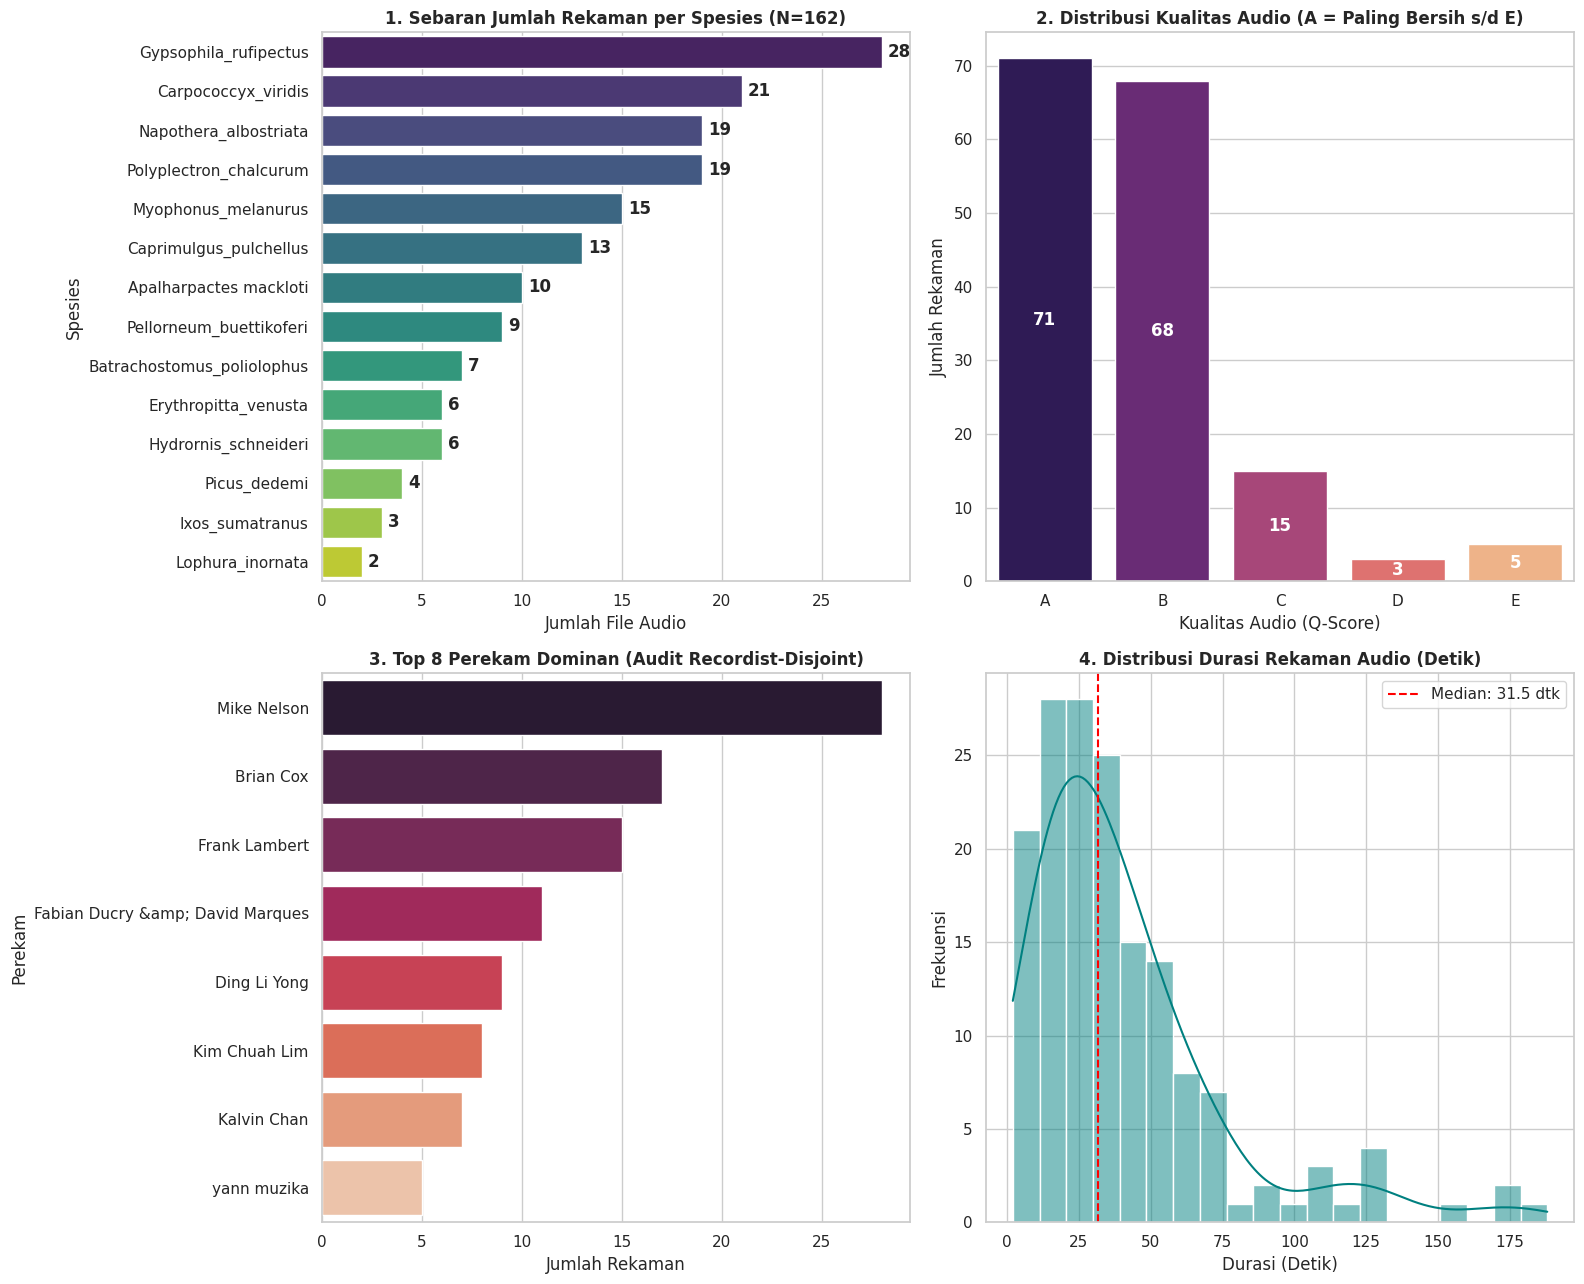

In [15]:
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
# Plot 1: Sebaran Jumlah Rekaman per Spesies
species_order = df['species_key'].value_counts().index
sns.countplot(data=df, y='species_key', order=species_order, ax=axes[0, 0], palette="viridis")
axes[0, 0].set_title("1. Sebaran Jumlah Rekaman per Spesies (N=162)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Jumlah File Audio")
axes[0, 0].set_ylabel("Spesies")
for i, count in enumerate(df['species_key'].value_counts()[species_order]):
    axes[0, 0].text(count + 0.3, i, str(count), va='center', fontweight='bold')
# Plot 2: Distribusi Kualitas Rekaman (Xeno-Canto Q-Score A-E)
sns.countplot(data=df, x='quality', order=['A', 'B', 'C', 'D', 'E'], ax=axes[0, 1], palette="magma")
axes[0, 1].set_title("2. Distribusi Kualitas Audio (A = Paling Bersih s/d E)", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Kualitas Audio (Q-Score)")
axes[0, 1].set_ylabel("Jumlah Rekaman")
for p in axes[0, 1].patches:
    h = p.get_height()
    if h > 0:
        axes[0, 1].annotate(f"{int(h)}", (p.get_x() + p.get_width() / 2., h / 2),
                            ha='center', va='center', color='white', fontweight='bold')
# Plot 3: Top 8 Perekam / Kontributor Dominan
top_rec = df['recordist'].value_counts().head(8).index
sns.countplot(data=df[df['recordist'].isin(top_rec)], y='recordist', order=top_rec, ax=axes[1, 0], palette="rocket")
axes[1, 0].set_title("3. Top 8 Perekam Dominan (Audit Recordist-Disjoint)", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Jumlah Rekaman")
axes[1, 0].set_ylabel("Perekam")
# Plot 4: Distribusi Durasi Rekaman (Detik)
sns.histplot(df['duration_seconds'].dropna(), bins=20, kde=True, ax=axes[1, 1], color="teal")
median_dur = df['duration_seconds'].median()
axes[1, 1].axvline(median_dur, color='red', linestyle='--', linewidth=1.5, label=f"Median: {median_dur:.1f} dtk")
axes[1, 1].set_title("4. Distribusi Durasi Rekaman Audio (Detik)", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Durasi (Detik)")
axes[1, 1].set_ylabel("Frekuensi")
axes[1, 1].legend()
plt.tight_layout()
plt.show()

In [16]:
print("  TABEL REKAPITULASI DETAIL 14 SPESIES BURUNG SUMATERA")
summary_table = df.groupby('species_key').agg(
    Total_Rekaman=('id', 'count'),
    Perekam_Unik=('recordist', 'nunique'),
    Durasi_Rata2_dtk=('duration_seconds', lambda x: round(x.mean(), 1)),
    Kualitas_A=('quality', lambda x: (x == 'A').sum()),
    Kualitas_B=('quality', lambda x: (x == 'B').sum()),
    Kualitas_C_sd_E=('quality', lambda x: (x.isin(['C', 'D', 'E'])).sum())
).reset_index()
display(summary_table)


  TABEL REKAPITULASI DETAIL 14 SPESIES BURUNG SUMATERA


,species_key,Total_Rekaman,Perekam_Unik,Durasi_Rata2_dtk,Kualitas_A,Kualitas_B,Kualitas_C_sd_E
0,Apalharpactes mackloti,10,6,47.9,4,4,2
1,Batrachostomus_poliolophus,7,5,25.0,3,1,3
2,Caprimulgus_pulchellus,13,8,27.2,6,4,3
3,Carpococcyx_viridis,21,10,44.0,13,6,2
4,Erythropitta_venusta,6,4,50.7,3,3,0
5,Gypsophila_rufipectus,28,12,59.5,14,14,0
6,Hydrornis_schneideri,6,5,34.3,1,2,3
7,Ixos_sumatranus,3,3,41.7,1,1,1
8,Lophura_inornata,2,1,116.5,0,0,2
9,Myophonus_melanurus,15,6,21.2,6,8,1


In [18]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

# 1. Tentukan corepath ke folder audio burung di Drive Anda
# Menggunakan pola pencarian otomatis di dalam folder TUGAS AKHIR
folder_search = glob.glob('/content/drive/MyDrive/TUGAS AKHIR/**/xeno_canto', recursive=True)

if folder_search:
    corepath = folder_search[0]
else:
    corepath = "/content/drive/MyDrive/TUGAS AKHIR/data/xeno_canto"

print(f"📁 Menggunakan corepath: {corepath}")

# 2. Loop os.walk mengumpulkan file .mp3 ke dalam variabel blist (Sesuai kode Pak Ardika)
blist = []
for root, dirs, files in os.walk(corepath):
    for file in files:
        if file.endswith(".mp3"):
            blist.append(os.path.join(root, file))

print('✅ Found ', len(blist), ' files in blist.')

📁 Menggunakan corepath: /content/drive/MyDrive/TUGAS AKHIR/data/xeno_canto
✅ Found  162  files in blist.


Selected random files number: [151, 113, 124, 10, 58]

🎵 Menampilkan Spectrogram: XC39501 - Sumatran Ground Cuckoo - Carpococcyx viridis.mp3


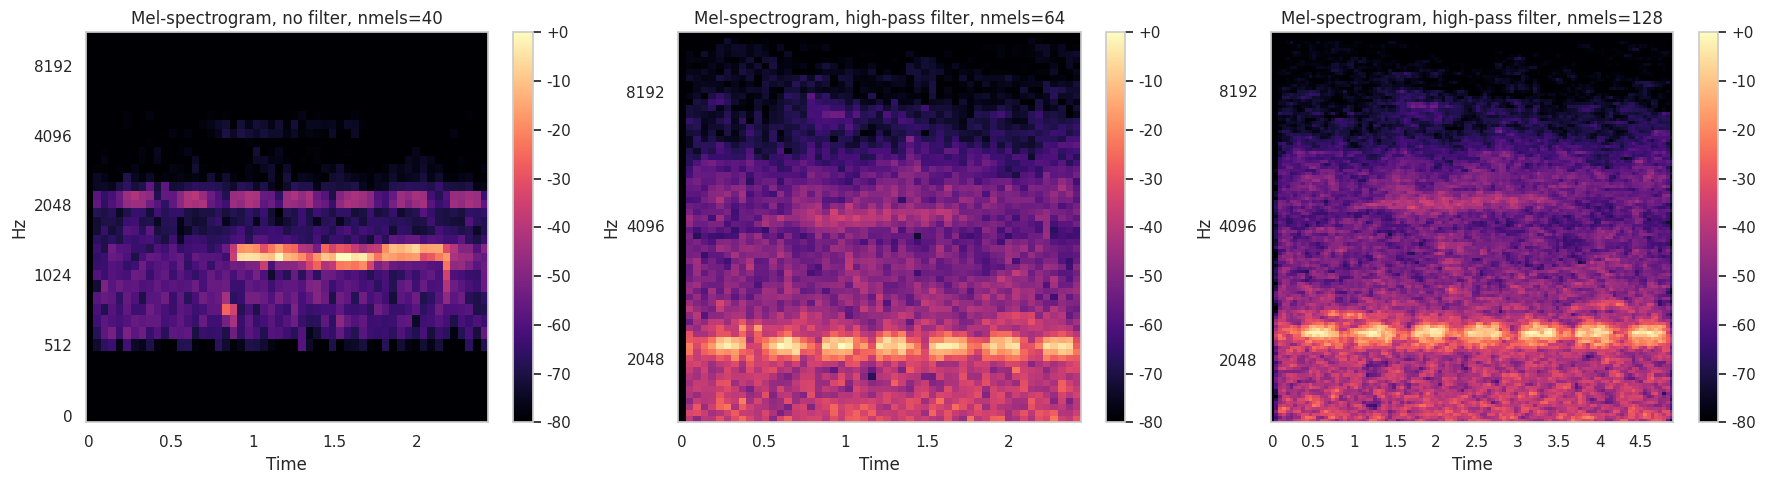

*******************************************

🎵 Menampilkan Spectrogram: XC70293 - Sumatran Wren-Babbler - Napothera albostriata albostriatus.mp3


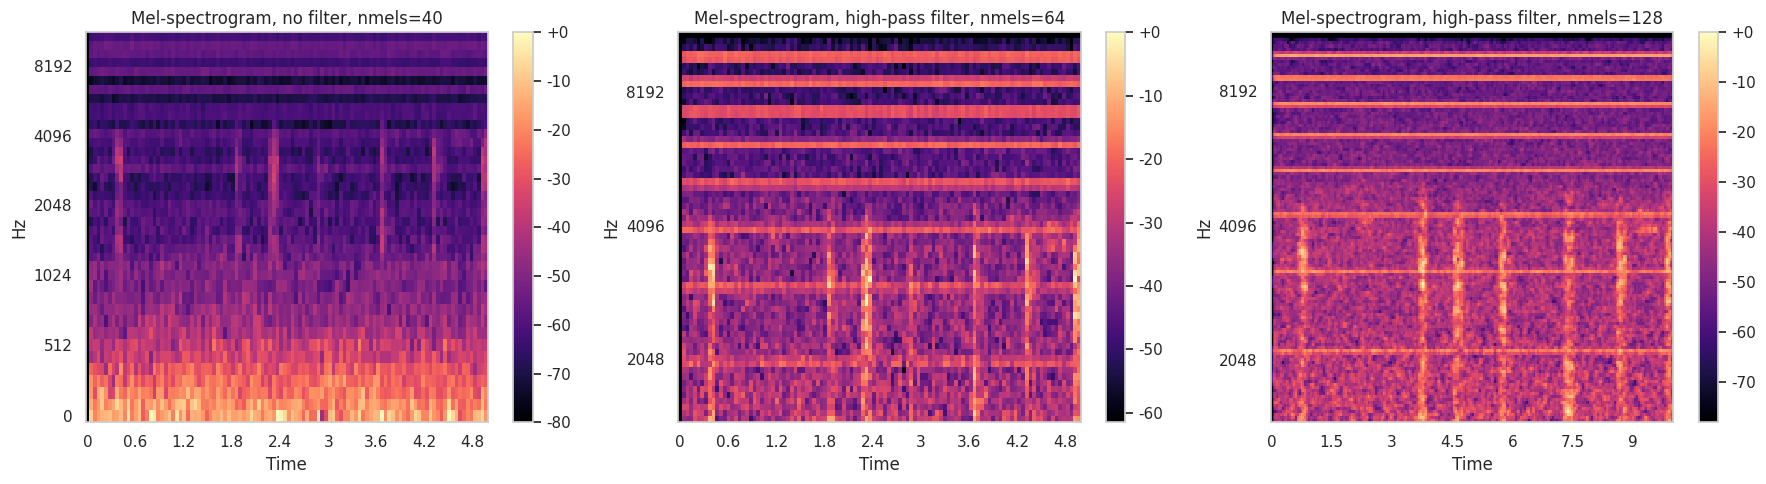

*******************************************

🎵 Menampilkan Spectrogram: XC431618 - Shiny Whistling Thrush - Myophonus melanurus.mp3


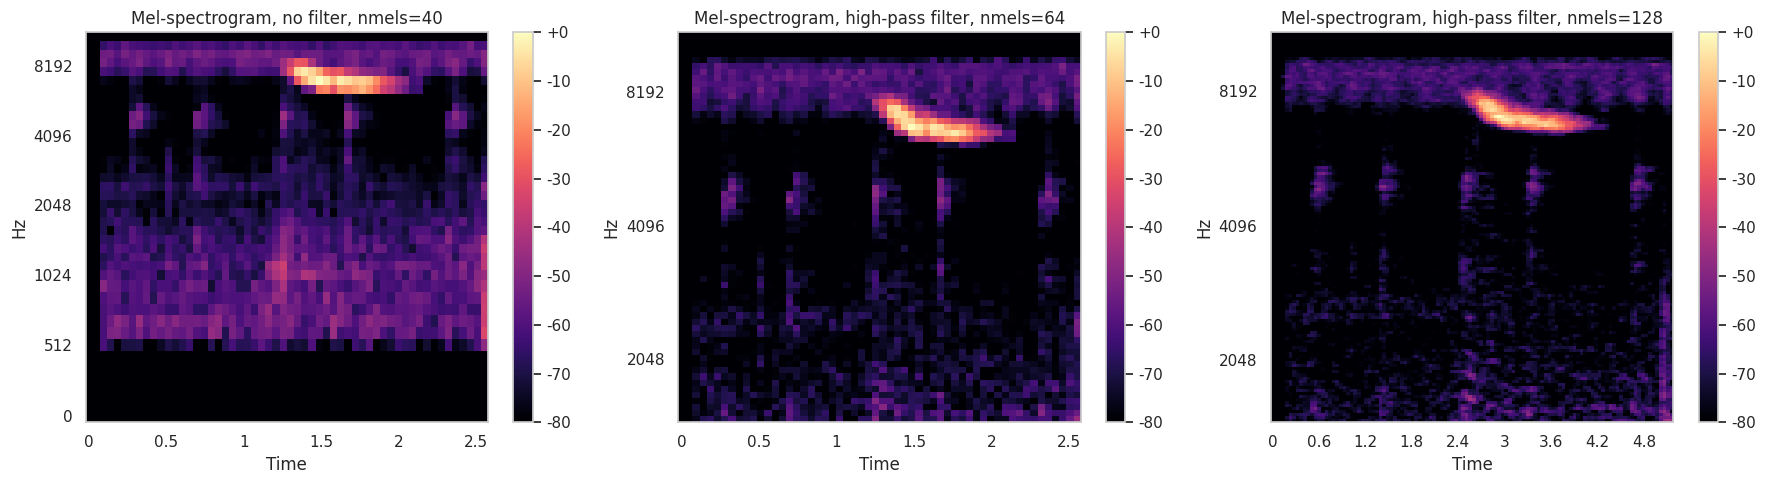

*******************************************

🎵 Menampilkan Spectrogram: XC393112 - Rusty-breasted Wren-Babbler - Gypsophila rufipectus.mp3


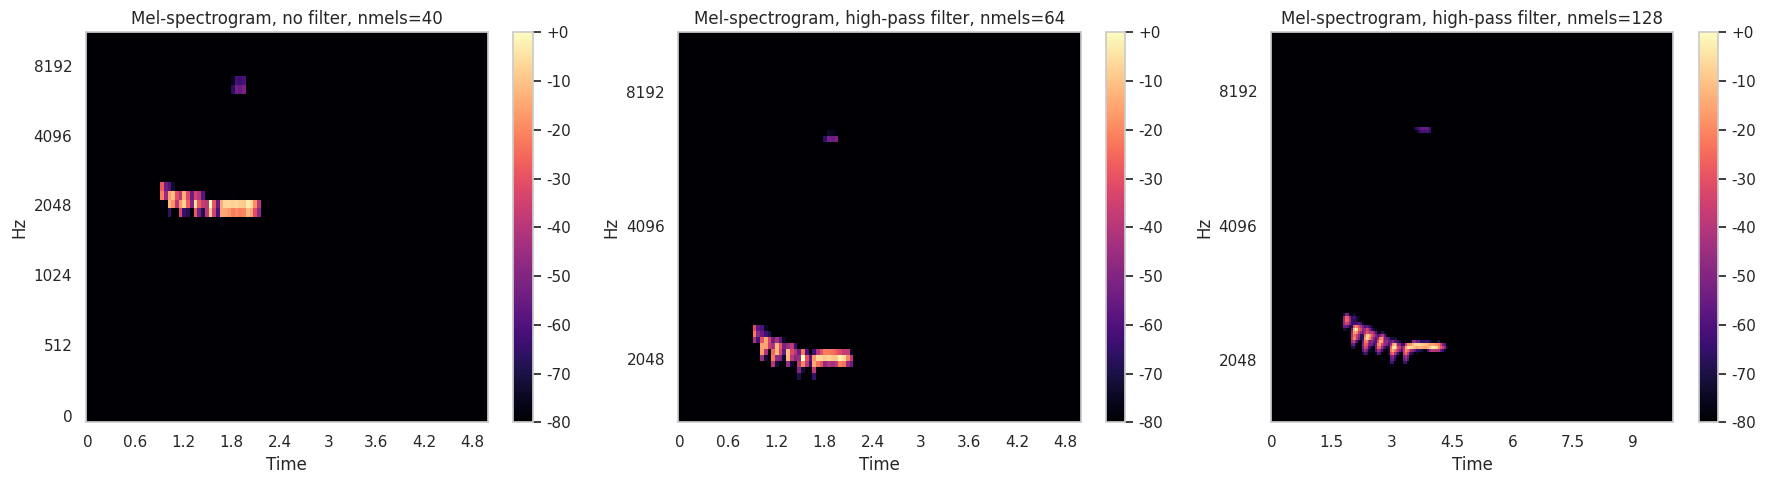

*******************************************

🎵 Menampilkan Spectrogram: XC374656 - Sumatran Trogon - Apalharpactes mackloti.mp3


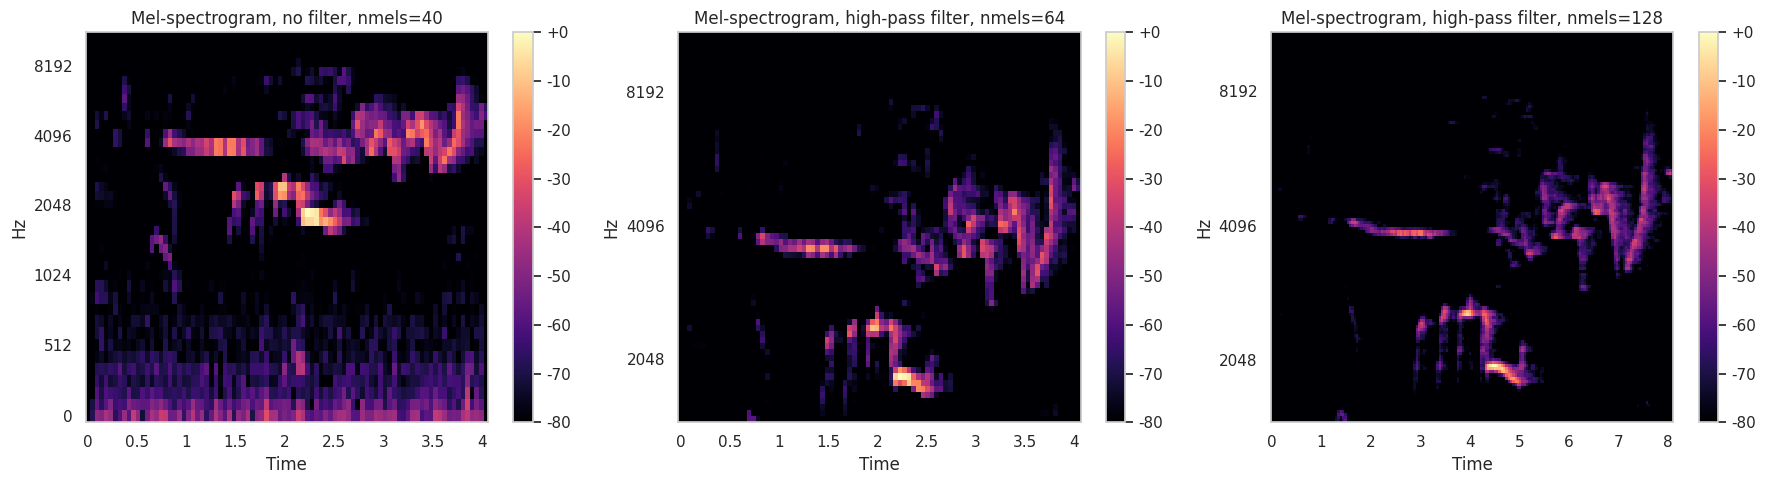

*******************************************


In [20]:
import matplotlib.pyplot as plt
from scipy import signal
import librosa
import librosa.display
import numpy as np
from random import sample

# Ambil 5 atau 10 file acak dari blist (sesuaikan jumlahnya)
sample_count = min(5, len(blist))
randFiles = sample(range(len(blist)), sample_count)
print('Selected random files number:', randFiles)

for audioFile in randFiles:
    file_path = blist[audioFile]
    print(f"\n🎵 Menampilkan Spectrogram: {os.path.basename(file_path)}")

    # Load audio 5 detik pertama
    data, sr = librosa.load(file_path, duration=5)

    N_FFT = 1024         # Number of frequency bins for Fast Fourier Transform
    HOP_SIZE = 1024      # Number of audio frames between STFT columns
    N_MELS = 40          # Mel band parameters
    WIN_SIZE = 512       # Number of samples in each STFT window
    WINDOW_TYPE = 'hann' # Windowing function
    FEATURE = 'mel'      # Feature representation

    f, axs = plt.subplots(1, 3, figsize=(18, 5))

    # -------------------------------------------------------------
    # 1. Mel-spectrogram, no filter, nmels=40
    # -------------------------------------------------------------
    plt.subplot(1, 3, 1)
    S1 = librosa.feature.melspectrogram(
        y=data, sr=sr, n_fft=N_FFT, hop_length=HOP_SIZE,
        n_mels=N_MELS, htk=True, fmin=0.0, fmax=sr/2.0
    )
    librosa.display.specshow(
        librosa.amplitude_to_db(S1, ref=np.max),
        sr=sr, hop_length=HOP_SIZE, x_axis='time', y_axis='mel'
    )
    plt.colorbar(format='%+2.0f')
    plt.title('Mel-spectrogram, no filter, nmels=' + str(N_MELS))

    # -------------------------------------------------------------
    # 2. Mel-spectrogram, high-pass filter, nmels=64
    # -------------------------------------------------------------
    N_MELS = 64
    FMIN = 1500          # High-pass filter frequency cutoff

    plt.subplot(1, 3, 2)
    S2 = librosa.feature.melspectrogram(
        y=data, sr=sr, n_fft=N_FFT, hop_length=HOP_SIZE,
        n_mels=N_MELS, htk=True, fmin=FMIN, fmax=sr/2.0
    )
    librosa.display.specshow(
        librosa.amplitude_to_db(S2, ref=np.max),
        sr=sr, hop_length=HOP_SIZE, x_axis='time', y_axis='mel', fmin=FMIN
    )
    plt.title('Mel-spectrogram, high-pass filter, nmels=' + str(N_MELS))
    plt.colorbar(format='%+2.0f')

    # -------------------------------------------------------------
    # 3. Mel-spectrogram, high-pass filter, nmels=128
    # -------------------------------------------------------------
    n_mels_3 = 128
    plt.subplot(1, 3, 3)
    S3 = librosa.feature.melspectrogram(y=data, sr=sr, n_mels=n_mels_3, fmin=FMIN)
    librosa.display.specshow(
        librosa.power_to_db(S3**2, ref=np.max),
        sr=sr, hop_length=HOP_SIZE, y_axis='mel', x_axis='time', fmin=FMIN
    )
    plt.title('Mel-spectrogram, high-pass filter, nmels=' + str(n_mels_3))
    plt.colorbar(format='%+2.0f')

    plt.tight_layout()
    plt.show()

    print('*******************************************')